# D9: which physical scale matters?

Compare assumed variation lengths and frozen reference properties. These are screening scenarios, not a calibrated flow or a CFD calculation.

In [1]:
import json
import numpy as np
from IPython.display import Image, display
from nscomp.d9 import STUDY, WRITING, load_parameters, reference, crossing_rows, generate
from nscomp.regimes import gas_diagnostics, carrier_power_length, averaging_cube_count
p=load_parameters()
model,gas,spacing=reference(p)

## The variation length changes the ordering

Each beta is explicitly assumed. A crossing below the reference speed means the screen is already exceeded at the reference.

In [2]:
for row in crossing_rows(p):
    print(f"beta={row['beta']:g}: Kn crossing {row['kn_crossing_speed_m_s']:.4g} m/s; first = {row['first_of_two_screens']}; already crossed = {row['kn_already_exceeded_at_reference']}")

beta=1: Kn crossing 148.6 m/s; first = Mach; already crossed = False
beta=0.1: Kn crossing 14.86 m/s; first = Kn; already crossed = False
beta=0.01: Kn crossing 1.486 m/s; first = Kn; already crossed = False
beta=0.001: Kn crossing 0.1486 m/s; first = Kn; already crossed = True


## Compare times without inventing a collapse time

The collision-rate proxy equals Kn times speed divided by mean thermal speed. It is not the actual symmetric strain rate.

In [3]:
speed=100.
length=.1*model.radius(speed)
values=gas_diagnostics(speed,length,gas)
print(json.dumps({k:float(v) for k,v in values.items()},indent=2))
print('Collision time proxy (s):',gas.collision_time_proxy)

{
  "mach": 0.289868710191092,
  "knudsen_proxy": 0.06730000000000003,
  "reynolds_proxy": 6.5029141982306164,
  "advection_time_proxy_s": 9.999999999999995e-09,
  "sound_crossing_time_s": 2.8986871019109187e-09,
  "diffusion_time_proxy_s": 6.502914198230614e-08,
  "collision_rate_proxy": 0.014464731049362049
}
Collision time proxy (s): 1.4464731049362042e-10


## Molecular averaging requires two separated lengths

A cube smaller than the flow variation must still contain many molecules. The particle count is a geometric expectation, not a universal validity test.

In [4]:
for separation in (1,10,100):
    print(f'L/d={separation}: expected count in cube of side 0.1L = {averaging_cube_count(separation*spacing,spacing,.1):g}')
print('Water mean spacing (nm):',spacing*1e9)

L/d=1: expected count in cube of side 0.1L = 0.001
L/d=10: expected count in cube of side 0.1L = 1
L/d=100: expected count in cube of side 0.1L = 1000
Water mean spacing (nm): 0.3107360588479975


## Reproduce the full map

The carrier comparison retains only bare powers and declared prefactors. Its outputs do not calibrate the paper's physical phase wavelength.

In [5]:
summary=generate()
print(json.dumps(summary,indent=2))

{
  "air_sound_speed_m_s": 344.98376845874935,
  "air_mean_thermal_speed_m_s": 465.2696256178799,
  "air_collision_time_proxy_s": 1.4464731049362042e-10,
  "water_mean_spacing_m": 3.107360588479975e-10,
  "air_mach_screen_speed_m_s": 103.4951305376248,
  "water_mach_screen_speed_m_s": 449.00976599999996,
  "beta_for_simultaneous_air_screens": 0.6965222285182147,
  "air_core_radius_at_mach_screen_m": 9.66229033970307e-06,
  "water_core_radius_at_mach_screen_m": 2.227123051038494e-06,
  "ceiling_bare_carrier_ratio_decrease_percent": 0.07812296302007748,
  "formal_endpoint_speed_m_s": 29979245.8,
  "actual_paper_gradient_evaluated": false,
  "actual_paper_pulse_wavelength_evaluated": false,
  "liquid_relaxation_evaluated": false,
  "full_dimensional_profile_calibration": false,
  "parameters_sha256": "bff76f5f3747e6dc53bf6dff7b2d745b93dc9a909dae8a3d4e183251d62a8017"
}


## Figures

Read the matching model-selection note for the next bounded compressible-equilibrium comparison.

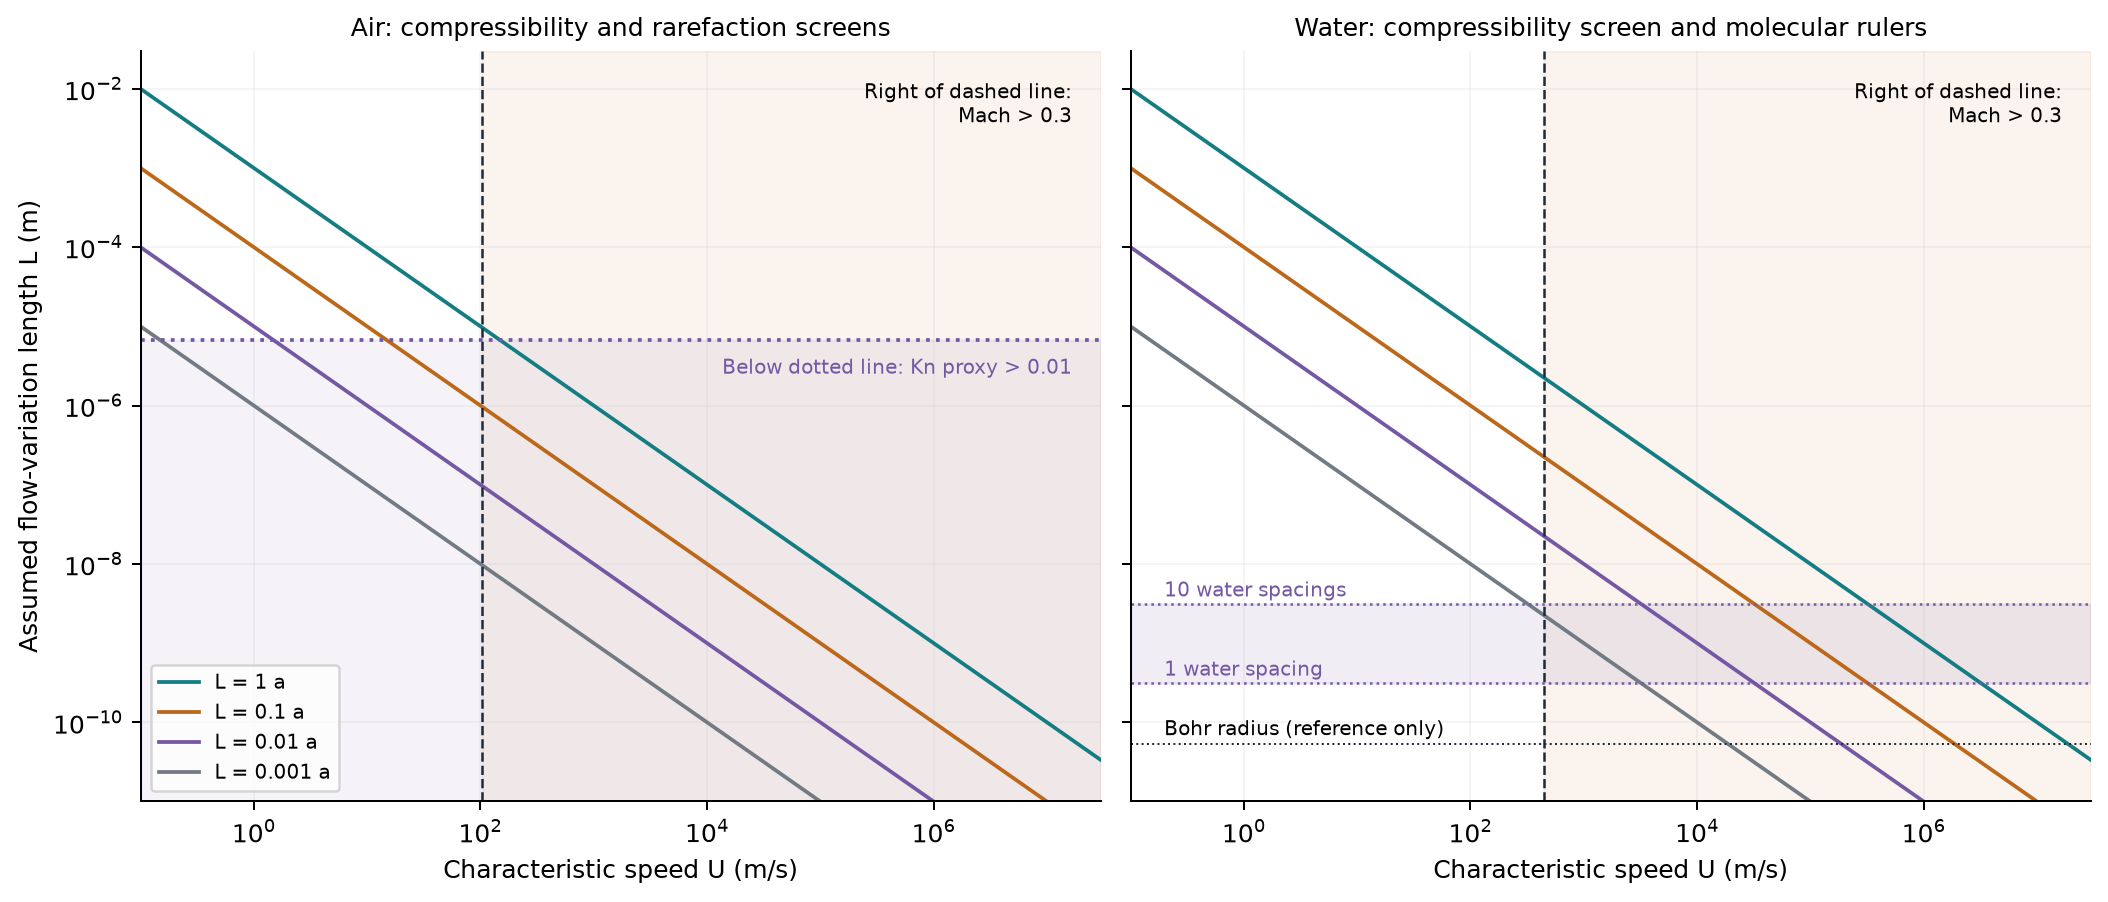

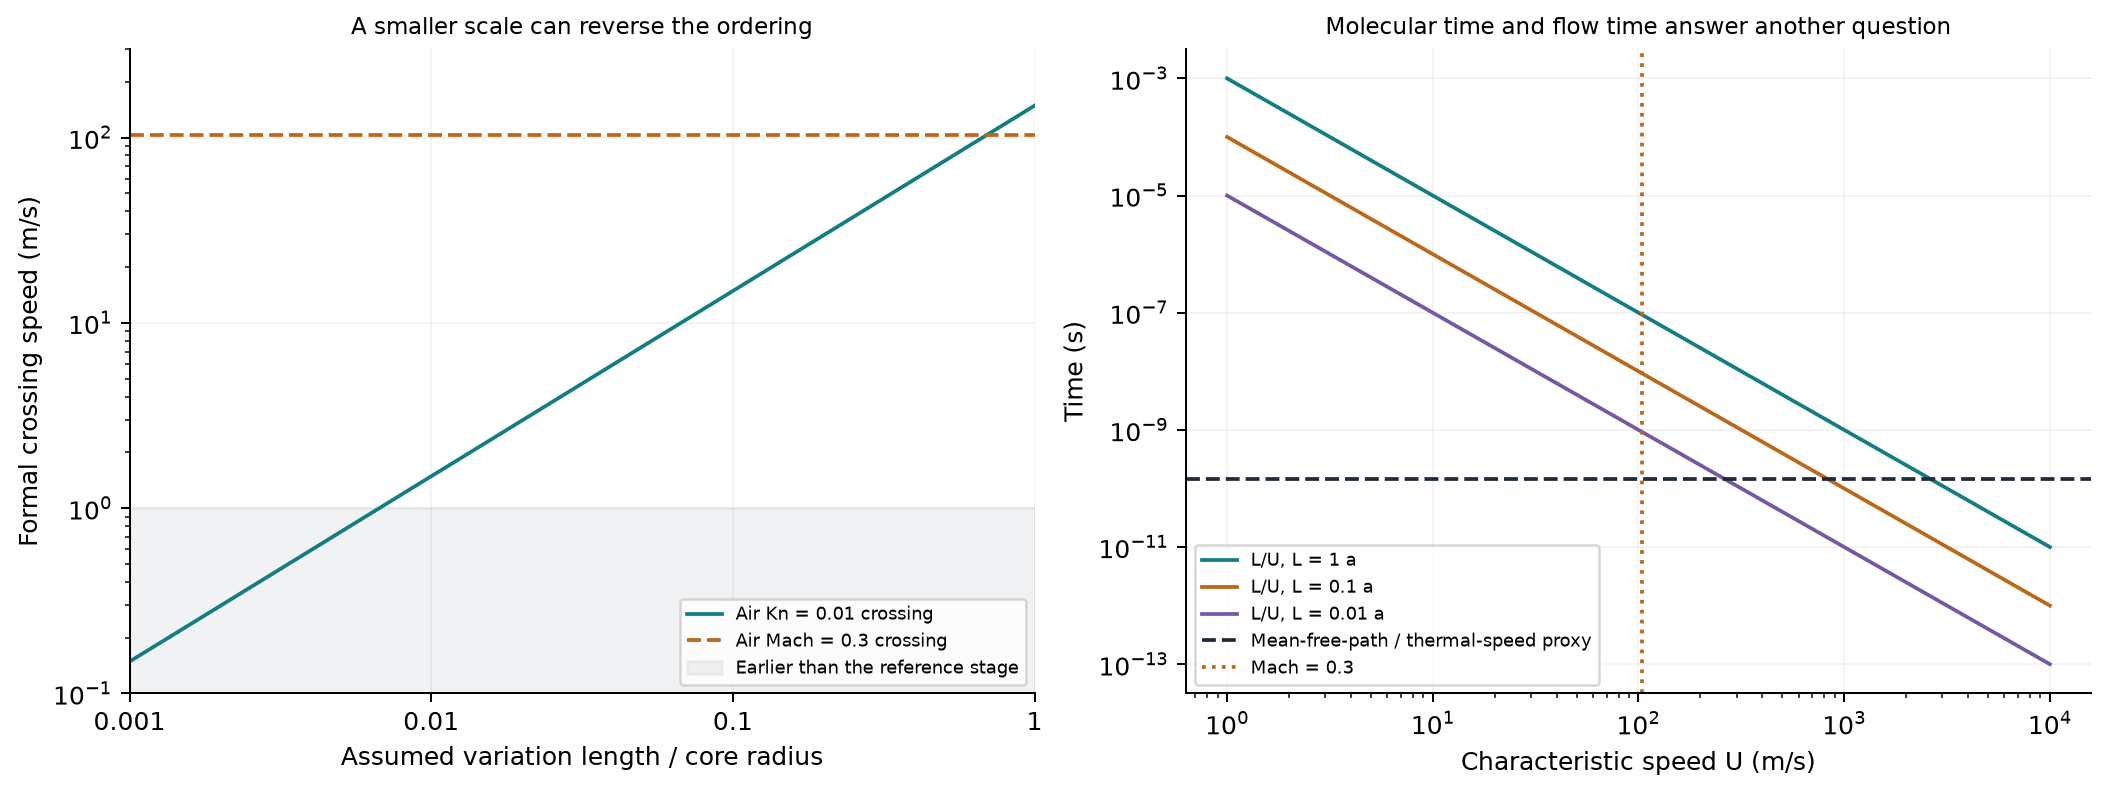

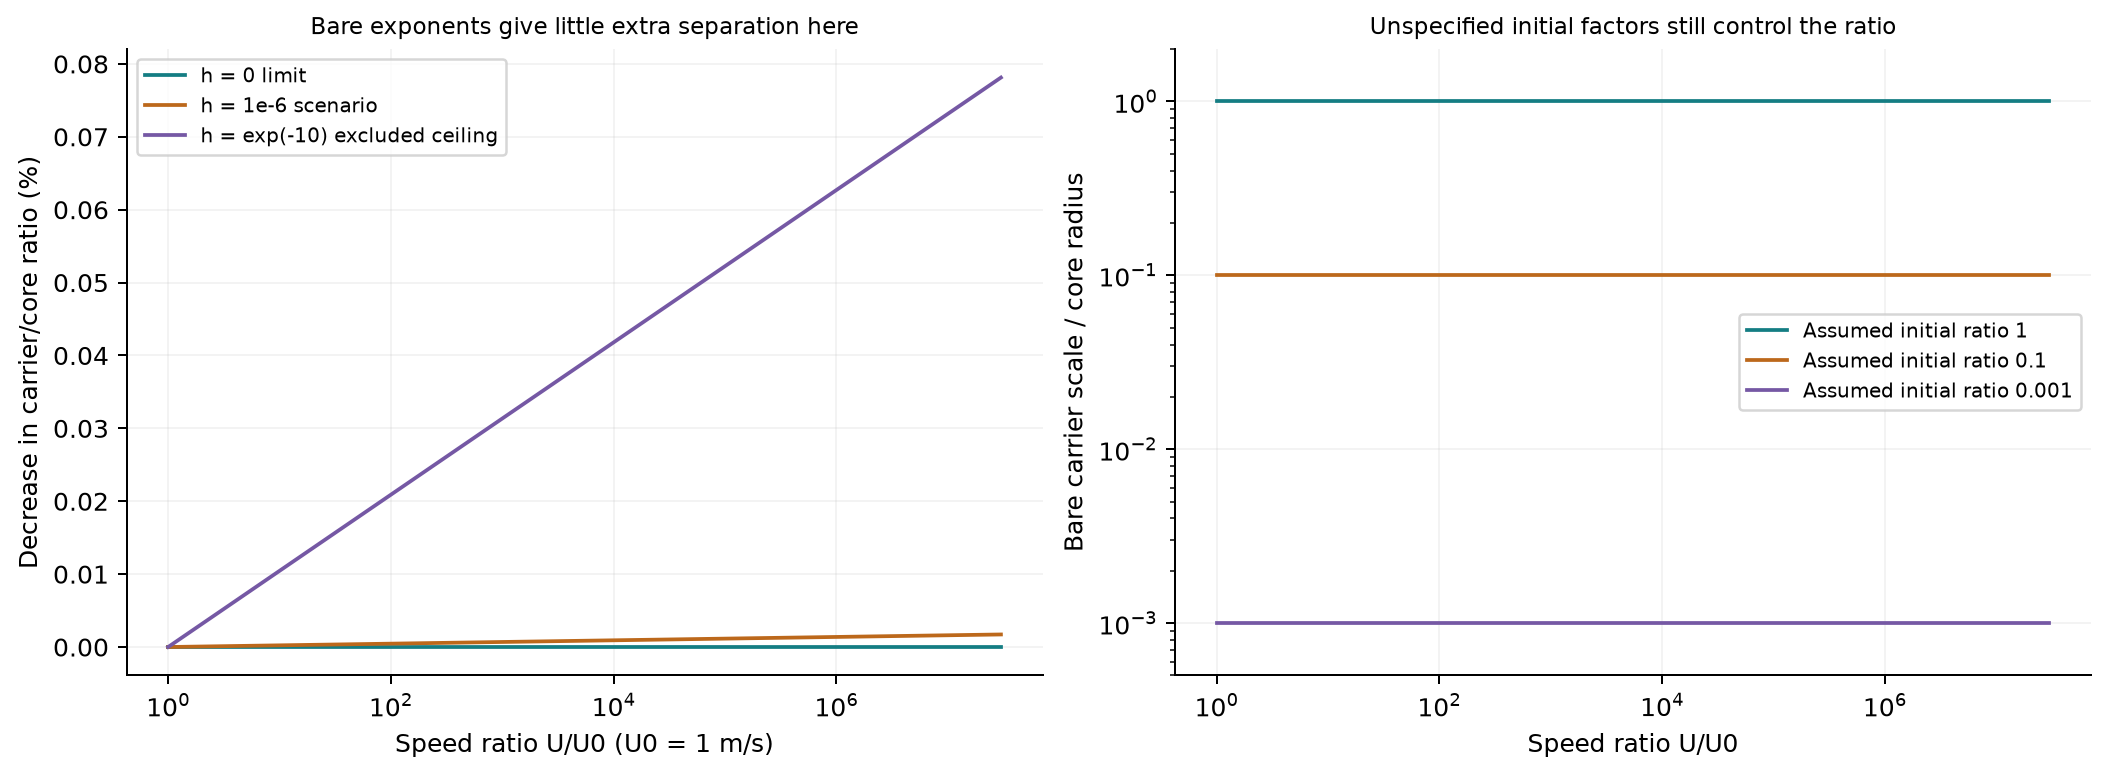

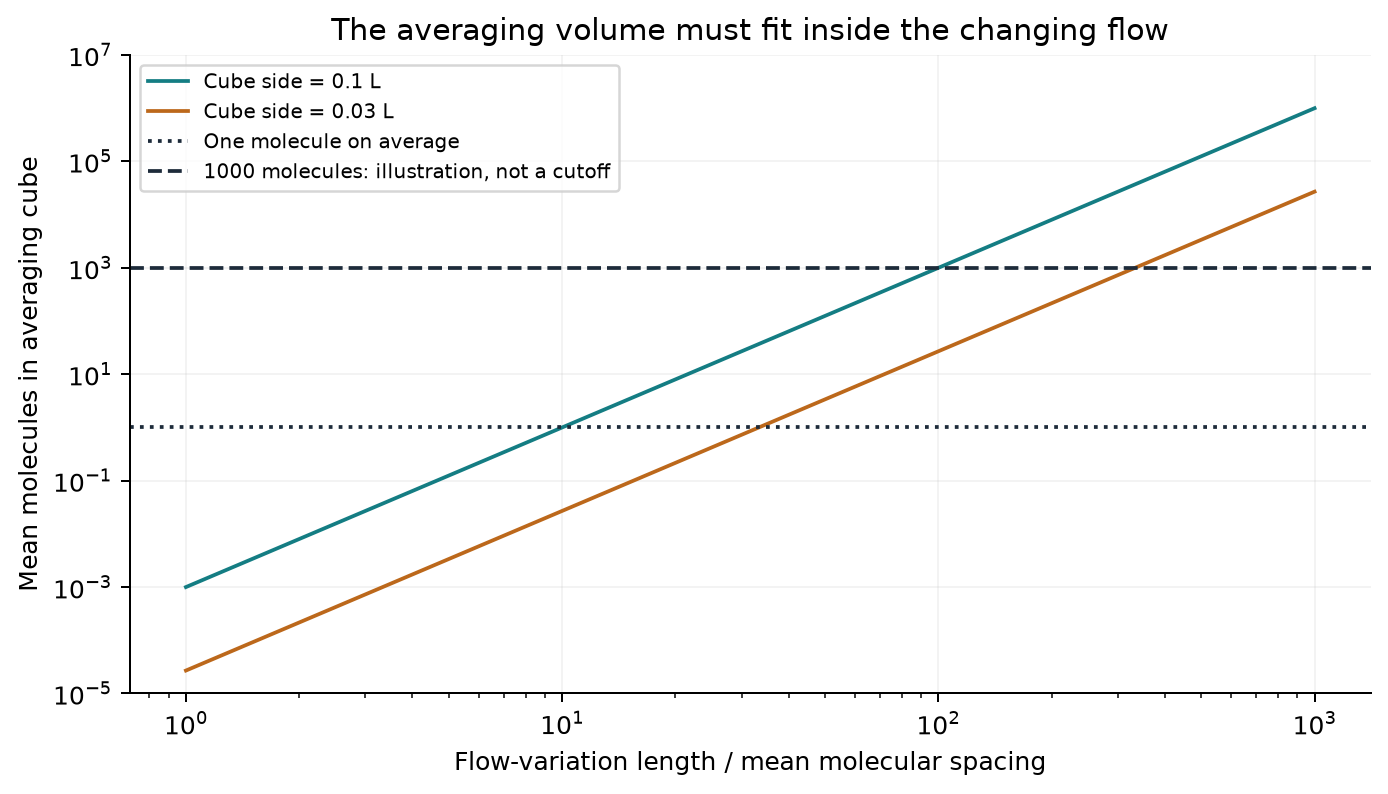

In [6]:
for name in ('01_physical_regime_map','02_screen_order_and_times','03_carrier_scale_audit','04_averaging_scale_separation'):
    display(Image(filename=str(WRITING/'figures'/f'{name}.png')))